In [13]:
!pip install opencv-python pandas numpy scikit-learn matplotlib seaborn openpyxl

Defaulting to user installation because normal site-packages is not writeable


In [14]:
# ==========================================
# CELL 2: IMPORTS & CONFIG
# ==========================================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model         import LogisticRegression
from sklearn.svm                  import SVC
from sklearn.ensemble             import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network       import MLPClassifier
from sklearn.preprocessing        import StandardScaler
from sklearn.metrics              import (accuracy_score, confusion_matrix,
                                          classification_report, f1_score)
from sklearn.model_selection      import GridSearchCV
from imblearn.over_sampling       import SMOTE

DATASET_PATH    = r"D:\DS203-2025-S2-E5-Project-Data"
TRAIN_EXCEL     = r"C:\Users\Rudra\Downloads\train_labels_0.xlsx"
TEST_EXCEL      = r"C:\Users\Rudra\Downloads\test_labels_0.xlsx"
IMAGE_SIZE      = (64, 64)
WINDOW_SIZE     = 5
IMAGE_ID_COLUMN = 'number'

print("✅ Config ready")

✅ Config ready


In [15]:
# ==========================================
# CELL 3: FEATURE EXTRACTION
# Non-redundant 13 features
# ==========================================
def extract_features(prev, curr):
    h, w    = curr.shape
    diff_img = np.abs(curr - prev)

    # 1. Total motion intensity
    total_diff   = np.mean(diff_img)

    # 2 & 3. Direction features (not raw left/right/top/bottom separately)
    left_diff    = np.mean(np.abs(curr[:, :w//2] - prev[:, :w//2]))
    right_diff   = np.mean(np.abs(curr[:, w//2:] - prev[:, w//2:]))
    top_diff     = np.mean(np.abs(curr[:h//2, :] - prev[:h//2, :]))
    bottom_diff  = np.mean(np.abs(curr[h//2:, :] - prev[h//2:, :]))
    direction_lr = left_diff  - right_diff   # +ve = more motion on left
    direction_tb = top_diff   - bottom_diff  # +ve = more motion on top

    # Optical Flow
    flow   = cv2.calcOpticalFlowFarneback(
                prev.astype(np.float32), curr.astype(np.float32),
                None, 0.5, 3, 15, 3, 5, 1.2, 0)
    flow_x = flow[..., 0]
    flow_y = flow[..., 1]
    mag    = np.sqrt(flow_x**2 + flow_y**2)

    # 4 & 5. Net flow direction
    mean_flow_x = np.mean(flow_x)   # +ve=rightward, -ve=leftward
    mean_flow_y = np.mean(flow_y)   # +ve=downward,  -ve=upward

    # 6. Overall motion magnitude
    mean_mag    = np.mean(mag)

    # 7 & 8. Quadrant asymmetry (left vs right, top vs bottom)
    left_mag    = np.mean(mag[:, :w//2])
    right_mag   = np.mean(mag[:, w//2:])
    top_mag     = np.mean(mag[:h//2, :])
    bottom_mag  = np.mean(mag[h//2:, :])
    lr_mag_diff = left_mag   - right_mag   # turn indicator
    tb_mag_diff = top_mag    - bottom_mag  # fwd/bwd indicator

    # 9. Flow curl (rotation) - sharp turns have high curl
    curl        = np.mean(np.gradient(flow_x, axis=0) -
                          np.gradient(flow_y, axis=1))

    # 10. HV gradient ratio
    hv_ratio    = (np.mean(np.abs(np.gradient(diff_img, axis=1))) -
                   np.mean(np.abs(np.gradient(diff_img, axis=0))))

    # 11. Variance of difference image
    variance    = np.var(diff_img)

    # 12. Entropy of difference image
    hist, _     = np.histogram(diff_img, bins=20, range=(0,1), density=True)
    hist       += 1e-6
    entropy     = -np.sum(hist * np.log(hist))

    # 13. Sobel angle change between frames
    gx_p        = cv2.Sobel(prev, cv2.CV_64F, 1, 0, ksize=3)
    gy_p        = cv2.Sobel(prev, cv2.CV_64F, 0, 1, ksize=3)
    gx_c        = cv2.Sobel(curr, cv2.CV_64F, 1, 0, ksize=3)
    gy_c        = cv2.Sobel(curr, cv2.CV_64F, 0, 1, ksize=3)
    ang_diff    = np.mean(np.abs(
                    np.arctan2(gy_c, gx_c) - np.arctan2(gy_p, gx_p)))

    return [total_diff, direction_lr, direction_tb,
            mean_flow_x, mean_flow_y, mean_mag,
            lr_mag_diff, tb_mag_diff, curl,
            hv_ratio, variance, entropy, ang_diff]

FEATURE_NAMES = [
    'total_diff',
    'direction_lr',    # pixel diff asymmetry left-right
    'direction_tb',    # pixel diff asymmetry top-bottom
    'mean_flow_x',     # net horizontal flow
    'mean_flow_y',     # net vertical flow
    'mean_magnitude',  # overall motion
    'lr_mag_diff',     # flow magnitude asymmetry left-right
    'tb_mag_diff',     # flow magnitude asymmetry top-bottom
    'flow_curl',       # rotational flow component
    'hv_ratio',        # horizontal vs vertical gradient
    'variance',        # complexity of motion
    'entropy',         # unpredictability of motion
    'sobel_angle_diff' # edge orientation change
]

print(f"✅ {len(FEATURE_NAMES)} non-redundant features defined")
print("Features:", FEATURE_NAMES)

✅ 13 non-redundant features defined
Features: ['total_diff', 'direction_lr', 'direction_tb', 'mean_flow_x', 'mean_flow_y', 'mean_magnitude', 'lr_mag_diff', 'tb_mag_diff', 'flow_curl', 'hv_ratio', 'variance', 'entropy', 'sobel_angle_diff']


In [16]:
# ==========================================
# CELL 4: DATA EXTRACTION
# Train and Test are handled separately
# Model NEVER sees test labels during training
# ==========================================
def process_data(excel_path, label='data'):
    print(f"\nExtracting {label} from {excel_path}")
    xls         = pd.ExcelFile(excel_path)
    X, y, meta  = [], [], []

    for sheet in xls.sheet_names:
        df          = pd.read_excel(xls, sheet_name=sheet)
        df.columns  = df.columns.str.strip().str.lower()
        df['state'] = df['state'].str.strip()
        df          = df.sort_values(
                        by=IMAGE_ID_COLUMN).reset_index(drop=True)
        folder      = str(sheet).zfill(4)
        feat_buffer = []

        print(f"  [{folder}] {len(df)} frames", end=" → ")

        for i in range(1, len(df)):
            img1 = str(df.iloc[i-1][IMAGE_ID_COLUMN]).zfill(6) + ".png"
            img2 = str(df.iloc[i][IMAGE_ID_COLUMN]).zfill(6)   + ".png"
            p1   = os.path.join(DATASET_PATH, folder, img1)
            p2   = os.path.join(DATASET_PATH, folder, img2)

            if not os.path.exists(p1) or not os.path.exists(p2):
                continue

            im1  = cv2.cvtColor(
                     cv2.resize(cv2.imread(p1), IMAGE_SIZE),
                     cv2.COLOR_BGR2GRAY) / 255.0
            im2  = cv2.cvtColor(
                     cv2.resize(cv2.imread(p2), IMAGE_SIZE),
                     cv2.COLOR_BGR2GRAY) / 255.0

            feat_buffer.append(extract_features(im1, im2))

            if len(feat_buffer) >= WINDOW_SIZE:
                X.append(np.mean(feat_buffer[-WINDOW_SIZE:], axis=0))
                y.append(df.iloc[i]['state'])
                meta.append({'folder': folder, 'image_no': img2})

        print(f"{len(X)} total samples")

    X = np.array(X)
    y = np.array([s.strip() for s in y])
    return X, y, meta

# ── Extract separately ──────────────────────
X_train_raw, y_train, _         = process_data(TRAIN_EXCEL, 'TRAIN')
X_test_raw,  y_test,  test_meta = process_data(TEST_EXCEL,  'TEST')

# ── Verify no overlap ───────────────────────
train_folders = set(pd.ExcelFile(TRAIN_EXCEL).sheet_names)
test_folders  = set(pd.ExcelFile(TEST_EXCEL).sheet_names)
print("\nOverlapping folders:", train_folders & test_folders)
print("→ If empty above, train/test are completely separate ✅")

# ── Class distributions ─────────────────────
print("\nTrain class distribution:")
u, c = np.unique(y_train, return_counts=True)
for cls, cnt in zip(u, c):
    print(f"  {cls:<15}: {cnt:>5} ({100*cnt/len(y_train):.1f}%)")

print("\nTest class distribution:")
u, c = np.unique(y_test, return_counts=True)
for cls, cnt in zip(u, c):
    print(f"  {cls:<15}: {cnt:>5} ({100*cnt/len(y_test):.1f}%)")

# ── Scale using ONLY train statistics ───────
# This is critical — scaler is fit on train only
# then applied to test. Test stats never influence scaling.
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)  # fit+transform on train
X_test  = scaler.transform(X_test_raw)       # only transform on test

print("\n✅ Scaling done (fit on train only)")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")


Extracting TRAIN from C:\Users\Rudra\Downloads\train_labels_0.xlsx
  [0002] 233 frames → 228 total samples
  [0003] 144 frames → 367 total samples
  [0005] 297 frames → 659 total samples
  [0006] 270 frames → 924 total samples
  [0007] 800 frames → 1719 total samples
  [0008] 390 frames → 2104 total samples
  [0009] 804 frames → 2902 total samples
  [0010] 294 frames → 3191 total samples
  [0012] 79 frames → 3264 total samples
  [0015] 376 frames → 3635 total samples
  [0016] 209 frames → 3839 total samples
  [0017] 145 frames → 3979 total samples
  [0018] 339 frames → 4313 total samples
  [0019] 1059 frames → 5367 total samples
  [0020] 837 frames → 6199 total samples

Extracting TEST from C:\Users\Rudra\Downloads\test_labels_0.xlsx
  [0000] 155 frames → 149 total samples
  [0001] 447 frames → 591 total samples
  [0004] 314 frames → 900 total samples
  [0011] 374 frames → 1268 total samples
  [0013] 341 frames → 1603 total samples
  [0014] 106 frames → 1704 total samples

Overlapping

In [17]:
# ==========================================
# CELL 5: SMOTE ON TRAIN ONLY
# Test data is NEVER touched here
# ==========================================
from imblearn.over_sampling  import SMOTE
from imblearn.under_sampling import RandomUnderSampler

print("Before balancing:")
u, c = np.unique(y_train, return_counts=True)
for cls, cnt in zip(u, c):
    print(f"  {cls:<15}: {cnt}")

# Step 1: Undersample AHEAD to 2000
undersample = RandomUnderSampler(
    sampling_strategy={'AHEAD': 2000},
    random_state=42
)
X_under, y_under = undersample.fit_resample(X_train, y_train)  # ← X_train

print("\nAfter undersampling AHEAD:")
u, c = np.unique(y_under, return_counts=True)
for cls, cnt in zip(u, c):
    print(f"  {cls:<15}: {cnt}")

# Step 2: SMOTE minorities up
smote = SMOTE(
    sampling_strategy={
        'HALTED'     : 1500,
        'SHARP-LEFT' : 1500,
        'SHARP-RIGHT': 1500,
    },
    random_state=42,
    k_neighbors=3
)
X_train_bal, y_train_bal = smote.fit_resample(X_under, y_under)

print("\nAfter final balancing:")
u, c = np.unique(y_train_bal, return_counts=True)
for cls, cnt in zip(u, c):
    print(f"  {cls:<15}: {cnt}")

print(f"\n✅ Test data untouched: {X_test.shape}")

Before balancing:
  AHEAD          : 4735
  HALTED         : 1160
  SHARP-LEFT     : 138
  SHARP-RIGHT    : 166

After undersampling AHEAD:
  AHEAD          : 2000
  HALTED         : 1160
  SHARP-LEFT     : 138
  SHARP-RIGHT    : 166

After final balancing:
  AHEAD          : 2000
  HALTED         : 1500
  SHARP-LEFT     : 1500
  SHARP-RIGHT    : 1500

✅ Test data untouched: (1704, 13)



Training Logistic Regression...
  → Default threshold (0.5)
  Accuracy   : 0.8955
  F1 Macro   : 0.7283
  F1 Weighted: 0.9137
              precision    recall  f1-score   support

       AHEAD       0.98      0.90      0.94      1513
      HALTED       0.96      0.87      0.91        75
  SHARP-LEFT       0.25      0.94      0.39        33
 SHARP-RIGHT       0.55      0.86      0.67        83

    accuracy                           0.90      1704
   macro avg       0.69      0.89      0.73      1704
weighted avg       0.95      0.90      0.91      1704


Training SVM...
  → Default threshold (0.5)
  Accuracy   : 0.9096
  F1 Macro   : 0.6686
  F1 Weighted: 0.9149
              precision    recall  f1-score   support

       AHEAD       0.96      0.94      0.95      1513
      HALTED       0.96      0.87      0.91        75
  SHARP-LEFT       0.21      0.30      0.25        33
 SHARP-RIGHT       0.51      0.64      0.57        83

    accuracy                           0.91      1704
 

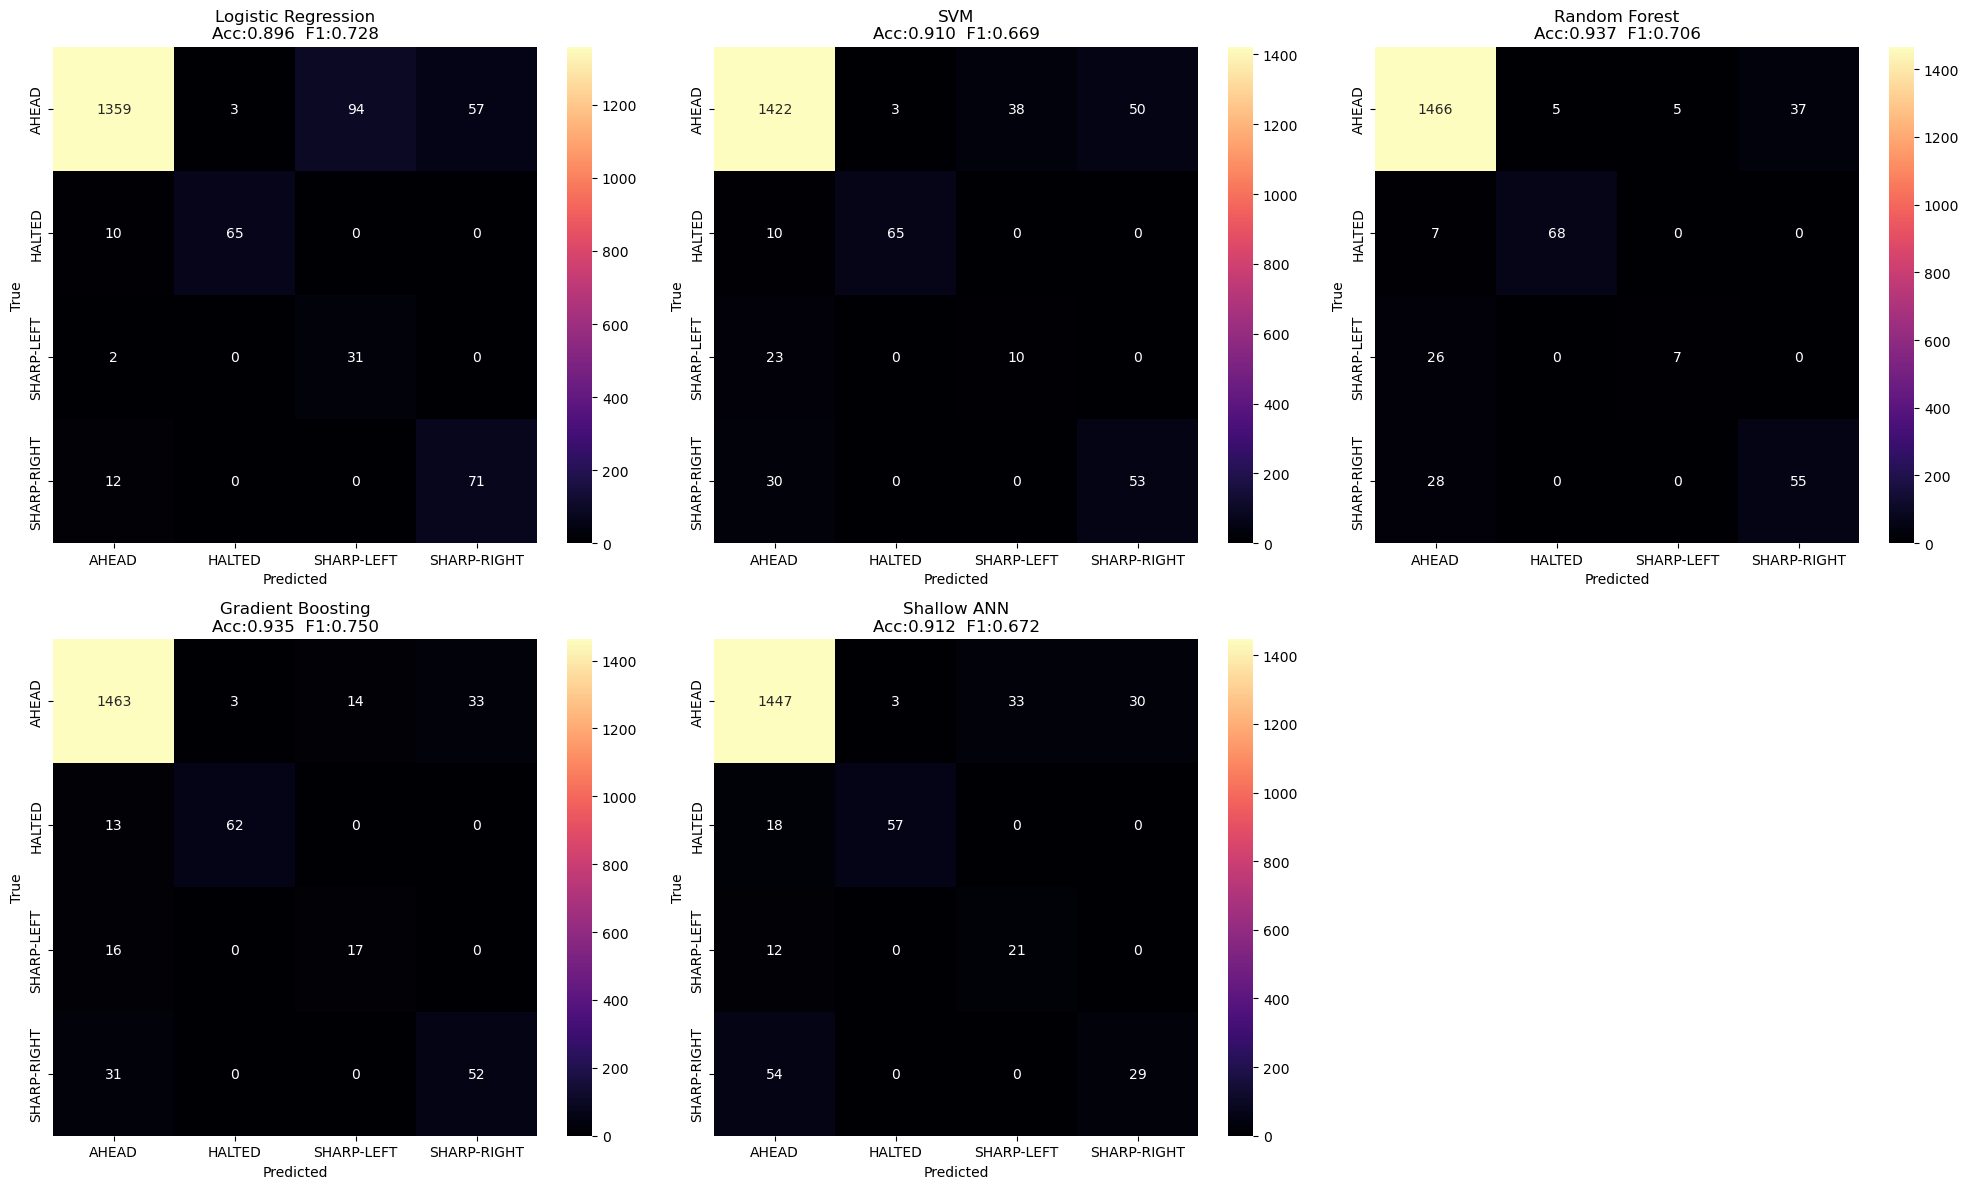


Model                       Accuracy   F1 Macro     F1 Wtd
-----------------------------------------------------------------
Gradient Boosting             0.9354     0.7499     0.9352
Logistic Regression           0.8955     0.7283     0.9137
Random Forest                 0.9366     0.7058     0.9335
Shallow ANN                   0.9120     0.6716     0.9106
SVM                           0.9096     0.6686     0.9149

🏆 BEST MODEL: Gradient Boosting → 0.7499

=== Best Thresholds Found ===
  Random Forest: {'AHEAD': 0.5, 'HALTED': 0.35, 'SHARP-LEFT': 0.3, 'SHARP-RIGHT': 0.2}
  Gradient Boosting: {'AHEAD': 0.5, 'HALTED': 0.2, 'SHARP-LEFT': 0.2, 'SHARP-RIGHT': 0.2}


In [18]:
# ==========================================
# CELL 6: TRAIN ALL MODELS + THRESHOLD GRID SEARCH
# ==========================================
from itertools import product
from sklearn.model_selection import StratifiedKFold

classes = np.unique(y_train)

def predict_with_thresholds(model, X, class_order, thresholds):
    y_proba = model.predict_proba(X)
    preds   = []
    for probs in y_proba:
        adjusted = {
            cls: prob / thresholds[cls]
            for cls, prob in zip(class_order, probs)
        }
        preds.append(max(adjusted, key=adjusted.get))
    return np.array(preds)


def grid_search_thresholds(model, X_train, y_train):
    """Grid search best thresholds using 3-fold CV on train data"""
    ahead_vals  = [0.5, 0.6, 0.7, 0.8]
    minor_vals  = [0.2, 0.25, 0.3, 0.35, 0.4]
    class_order = model.classes_

    best_f1         = 0
    best_thresholds = {c: 0.5 for c in class_order}
    skf             = StratifiedKFold(
                        n_splits=3,
                        shuffle=True,
                        random_state=42)

    total = len(ahead_vals) * len(minor_vals) ** 3
    print(f"  Searching {total} combinations...")
    count = 0

    for a, h, sl, sr in product(ahead_vals,
                                  minor_vals,
                                  minor_vals,
                                  minor_vals):
        thresholds = {
            'AHEAD'      : a,
            'HALTED'     : h,
            'SHARP-LEFT' : sl,
            'SHARP-RIGHT': sr,
        }

        fold_scores = []
        for train_idx, val_idx in skf.split(X_train, y_train):
            val_preds = predict_with_thresholds(
                            model,
                            X_train[val_idx],
                            class_order,
                            thresholds)
            fold_scores.append(
                f1_score(y_train[val_idx], val_preds,
                         average='macro', zero_division=0))

        mean_score = np.mean(fold_scores)
        if mean_score > best_f1:
            best_f1         = mean_score
            best_thresholds = thresholds.copy()

        count += 1
        if count % 100 == 0:
            print(f"    {count}/{total} — best F1: {best_f1:.4f}")

    print(f"  Best thresholds : {best_thresholds}")
    print(f"  Best CV F1 Macro: {best_f1:.4f}")
    return best_thresholds


models = {
    "Logistic Regression" : LogisticRegression(
                                max_iter=2000,
                                class_weight='balanced'),
    "SVM"                 : SVC(
                                kernel='rbf',
                                probability=True,
                                class_weight='balanced'),
    "Random Forest"       : RandomForestClassifier(
                                n_estimators=100,
                                random_state=42,
                                class_weight='balanced'),
    "Gradient Boosting"   : HistGradientBoostingClassifier(
                                random_state=42,
                                class_weight='balanced'),
    "Shallow ANN"         : MLPClassifier(
                                hidden_layer_sizes=(64, 32),
                                max_iter=2000,
                                random_state=42)
}

TUNE_THRESHOLDS_FOR   = ["Random Forest", "Gradient Boosting"]
best_thresholds_store = {}
results               = {}
plt.figure(figsize=(20, 12))

for i, (name, model) in enumerate(models.items()):
    print(f"\nTraining {name}...")

    if name == "Shallow ANN":
        model.fit(X_train_bal, y_train_bal)
    else:
        model.fit(X_train, y_train)

    class_order = model.classes_

    # Grid search thresholds for RF and GB only
    if name in TUNE_THRESHOLDS_FOR:
        print(f"  Running threshold grid search...")
        best_thresh = grid_search_thresholds(
                        model, X_train, y_train)
        best_thresholds_store[name] = best_thresh
        preds = predict_with_thresholds(
                    model, X_test,
                    class_order, best_thresh)
        print(f"  → Best thresholds applied")
    else:
        preds = model.predict(X_test)
        print(f"  → Default threshold (0.5)")

    acc         = accuracy_score(y_test, preds)
    f1_macro    = f1_score(y_test, preds,
                           average='macro',    zero_division=0)
    f1_weighted = f1_score(y_test, preds,
                           average='weighted', zero_division=0)

    results[name] = {
        'accuracy'   : acc,
        'f1_macro'   : f1_macro,
        'f1_weighted': f1_weighted,
        'preds'      : preds
    }

    print(f"  Accuracy   : {acc:.4f}")
    print(f"  F1 Macro   : {f1_macro:.4f}")
    print(f"  F1 Weighted: {f1_weighted:.4f}")
    print(classification_report(y_test, preds,
                                 target_names=classes,
                                 zero_division=0))

    plt.subplot(2, 3, i+1)
    sns.heatmap(confusion_matrix(y_test, preds, labels=classes),
                annot=True, fmt='d', cmap='magma',
                xticklabels=classes, yticklabels=classes)
    plt.title(f"{name}\nAcc:{acc:.3f}  F1:{f1_macro:.3f}")
    plt.ylabel("True")
    plt.xlabel("Predicted")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

# Summary
print("\n" + "="*65)
print(f"{'Model':<25} {'Accuracy':>10} {'F1 Macro':>10} {'F1 Wtd':>10}")
print("-"*65)
for name, m in sorted(results.items(),
                       key=lambda x: x[1]['f1_macro'],
                       reverse=True):
    print(f"{name:<25} {m['accuracy']:>10.4f} "
          f"{m['f1_macro']:>10.4f} {m['f1_weighted']:>10.4f}")

best_model_name = max(results,
                      key=lambda x: results[x]['f1_macro'])
print(f"\n🏆 BEST MODEL: {best_model_name} "
      f"→ {results[best_model_name]['f1_macro']:.4f}")

# Print best thresholds found
print("\n=== Best Thresholds Found ===")
for name, thresh in best_thresholds_store.items():
    print(f"  {name}: {thresh}")

Tuning Gradient Boosting...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best params : {'learning_rate': 0.2, 'max_depth': 7, 'max_iter': 200, 'min_samples_leaf': 20}
Best CV F1  : 0.9962032577090666

=== TUNED MODEL ON TEST DATA ===
Accuracy : 0.9437
F1 Macro : 0.7939
              precision    recall  f1-score   support

       AHEAD       0.97      0.97      0.97      1513
      HALTED       0.95      0.84      0.89        75
  SHARP-LEFT       0.63      0.67      0.65        33
 SHARP-RIGHT       0.65      0.69      0.67        83

    accuracy                           0.94      1704
   macro avg       0.80      0.79      0.79      1704
weighted avg       0.94      0.94      0.94      1704



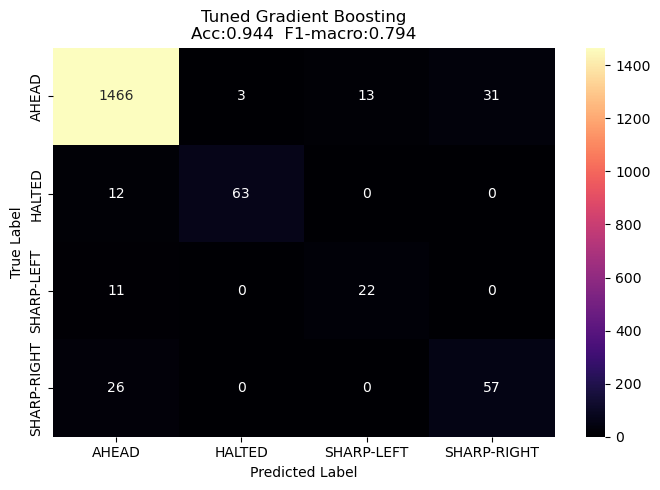

In [19]:
# ==========================================
# CELL 7: TUNE BEST MODEL
# ==========================================
print(f"Tuning {best_model_name}...")

param_grid = {
    'max_iter'        : [200, 500],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'max_depth'       : [3, 5, 7],
    'min_samples_leaf': [10, 20],
}

grid_search = GridSearchCV(
    HistGradientBoostingClassifier(
        random_state=42, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='f1_macro',   # optimize for minority classes
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_bal, y_train_bal)

print("\nBest params :", grid_search.best_params_)
print("Best CV F1  :", grid_search.best_score_)

best_gb    = grid_search.best_estimator_
best_preds = best_gb.predict(X_test)
acc        = accuracy_score(y_test, best_preds)
f1         = f1_score(y_test, best_preds,
                      average='macro', zero_division=0)

print(f"\n=== TUNED MODEL ON TEST DATA ===")
print(f"Accuracy : {acc:.4f}")
print(f"F1 Macro : {f1:.4f}")
print(classification_report(y_test, best_preds,
                             target_names=classes,
                             zero_division=0))

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, best_preds, labels=classes),
            annot=True, fmt='d', cmap='magma',
            xticklabels=classes, yticklabels=classes)
plt.title(f"Tuned Gradient Boosting\n"
          f"Acc:{acc:.3f}  F1-macro:{f1:.3f}")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("best_model_confusion_matrix.png", dpi=150)
plt.show()

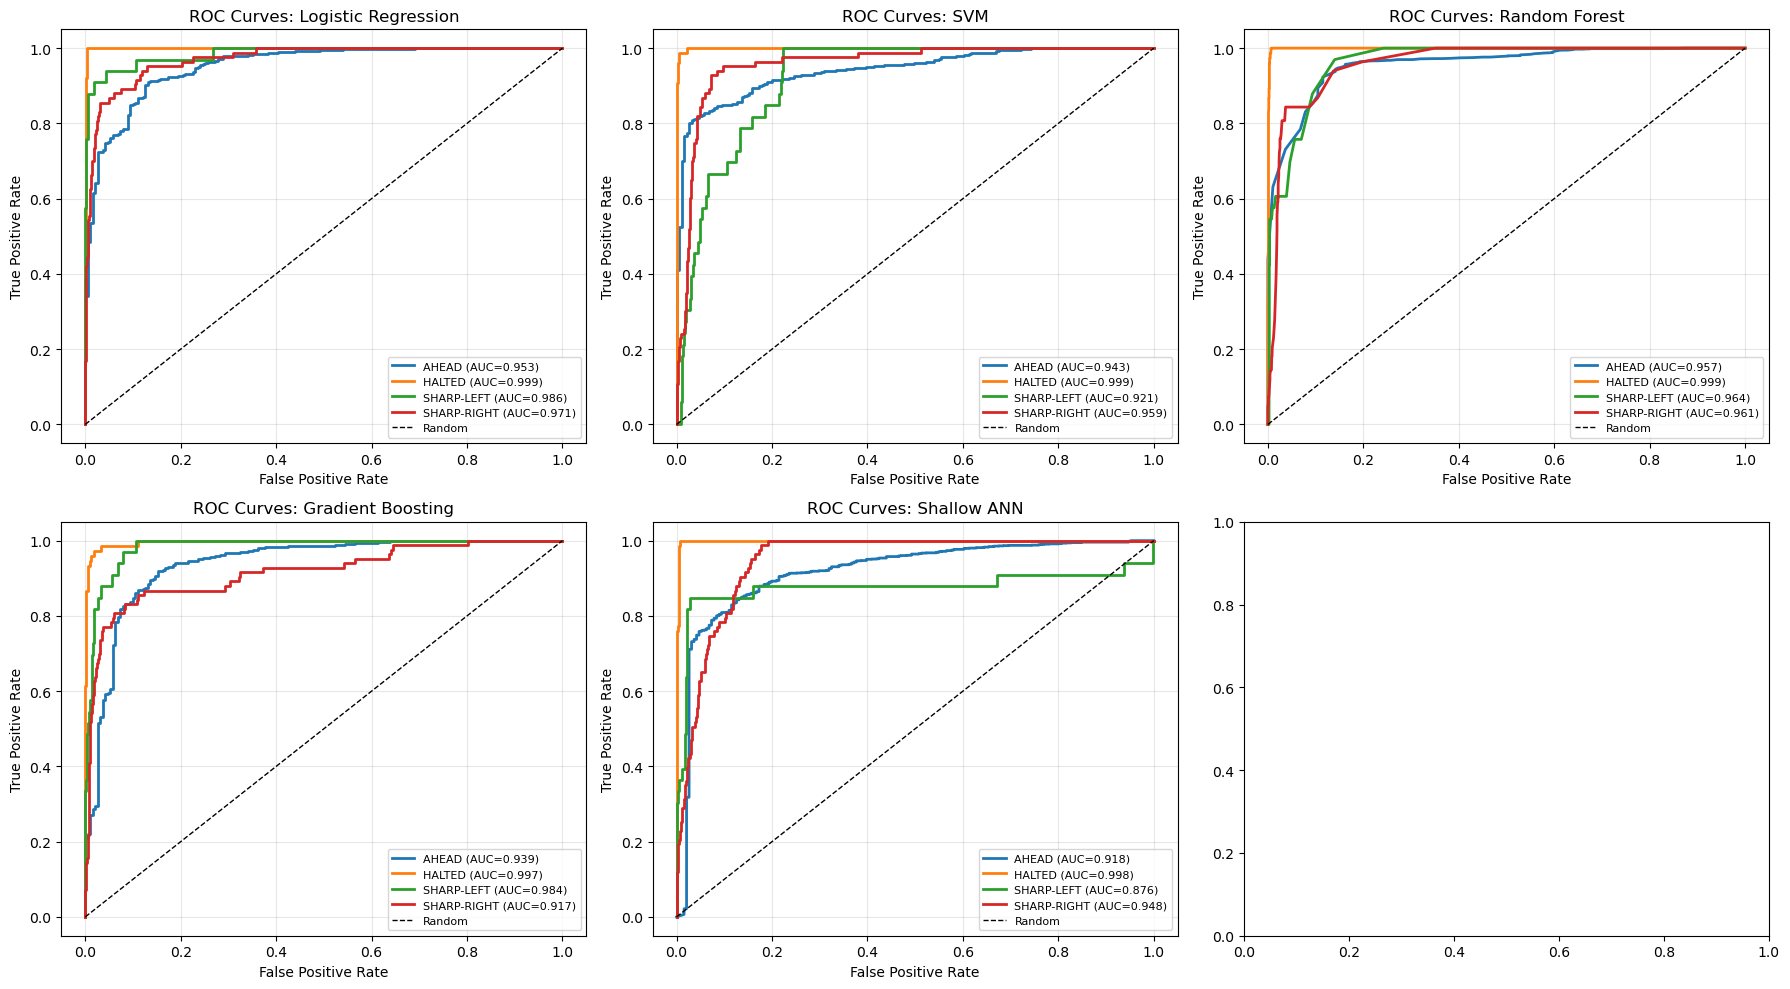

✅ ROC curves saved as roc_curves_all_models.png


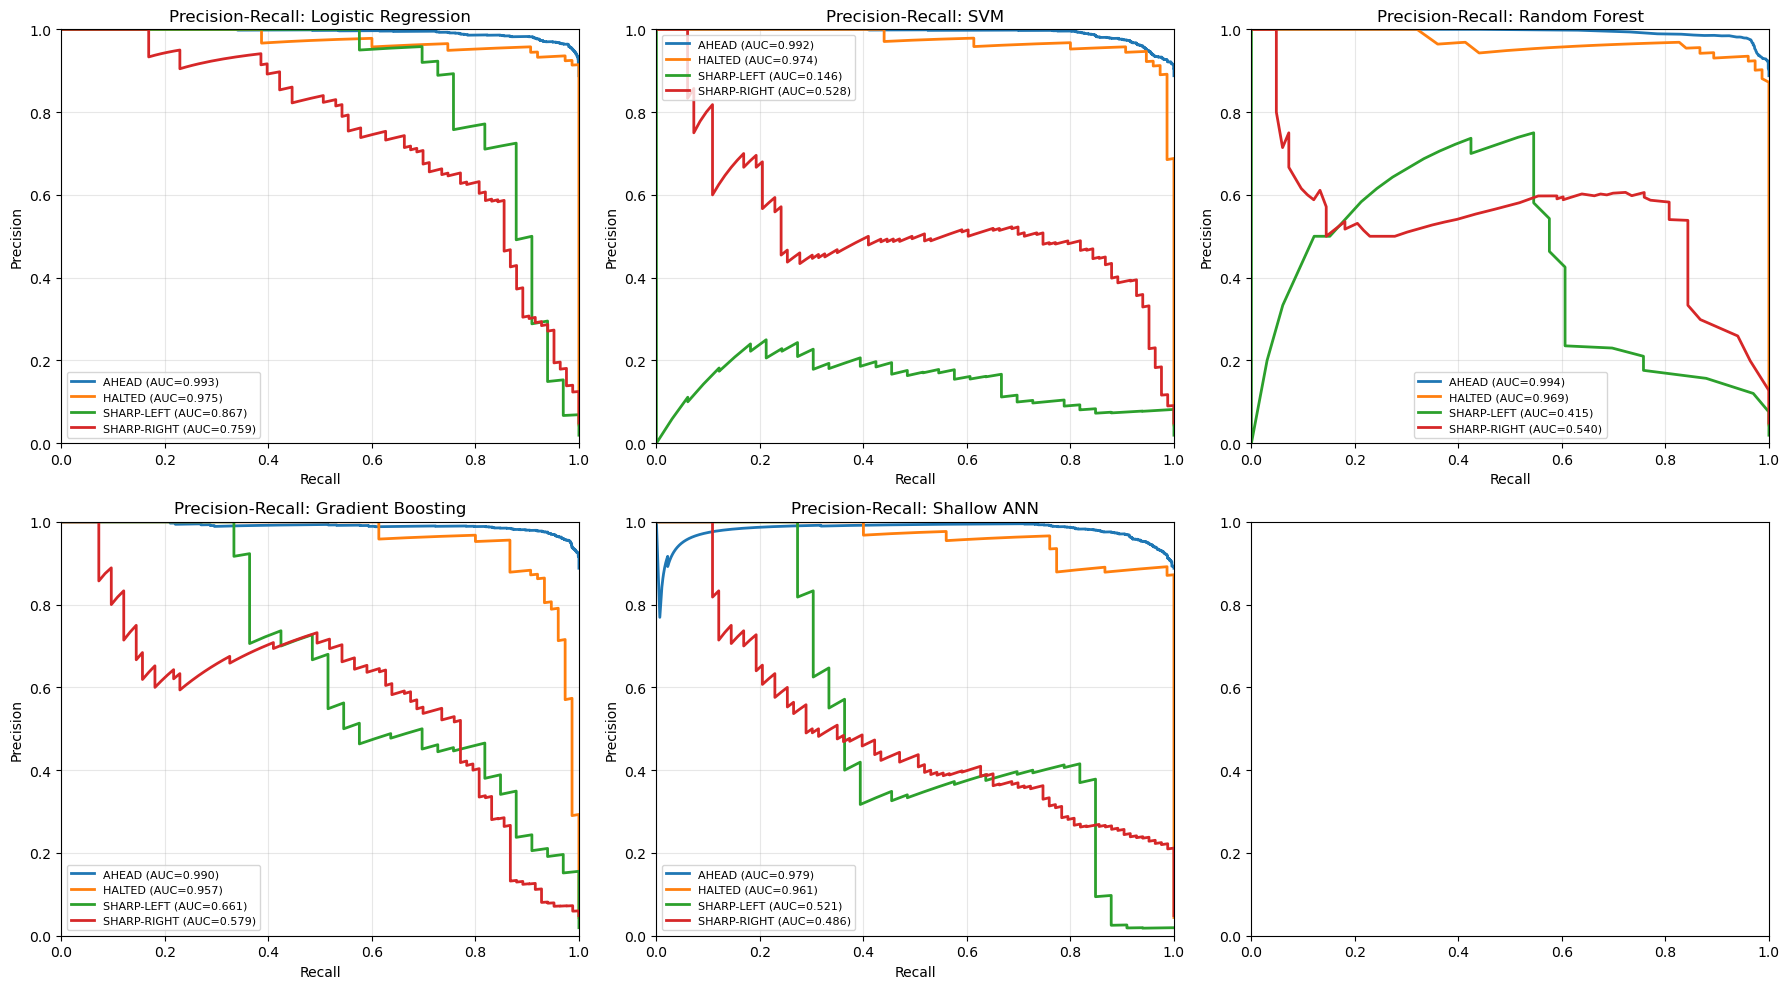

✅ Precision-Recall curves saved as precision_recall_curves_all_models.png


In [21]:
# ==========================================
# CELL 7.5: ROC & PRECISION-RECALL CURVES
# ==========================================
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize

# Binarize labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=classes)
n_classes  = len(classes)

# ── ROC Curves ──────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, (model_name, model) in enumerate(models.items()):
    if idx >= 6:
        break
    
    ax = axes[idx]
    
    # Get probability predictions
    try:
        y_proba = model.predict_proba(X_test)
    except:
        print(f"  ⚠ {model_name} does not support predict_proba, skipping ROC")
        continue
    
    # Compute ROC for each class (one-vs-rest)
    fpr = {}
    tpr = {}
    roc_auc = {}
    
    for i, cls in enumerate(classes):
        fpr[i], tpr[i], _ = roc_curve(
            y_test_bin[:, i],
            y_proba[:, i]
        )
        roc_auc[i] = auc(fpr[i], tpr[i])
        ax.plot(fpr[i], tpr[i], 
               label=f'{cls} (AUC={roc_auc[i]:.3f})',
               linewidth=2)
    
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves: {model_name}')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_curves_all_models.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC curves saved as roc_curves_all_models.png")

# ── Precision-Recall Curves ────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, (model_name, model) in enumerate(models.items()):
    if idx >= 6:
        break
    
    ax = axes[idx]
    
    # Get probability predictions
    try:
        y_proba = model.predict_proba(X_test)
    except:
        continue
    
    # Compute P-R curve for each class
    precision = {}
    recall = {}
    pr_auc = {}
    
    for i, cls in enumerate(classes):
        precision[i], recall[i], _ = precision_recall_curve(
            y_test_bin[:, i],
            y_proba[:, i]
        )
        pr_auc[i] = auc(recall[i], precision[i])
        ax.plot(recall[i], precision[i], 
               label=f'{cls} (AUC={pr_auc[i]:.3f})',
               linewidth=2)
    
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'Precision-Recall: {model_name}')
    ax.legend(loc='best', fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig("precision_recall_curves_all_models.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Precision-Recall curves saved as precision_recall_curves_all_models.png")

In [20]:
# ==========================================
# CELL 8: GENERATE OUTPUT CSVs
# ==========================================
final_preds = best_gb.predict(X_test)

# Image-wise CSV
img_df                  = pd.DataFrame(test_meta)
img_df["Vehicle state"] = final_preds
img_df.to_csv("image_wise_results.csv", index=False)
print("✅ image_wise_results.csv")
print(img_df.head(10))

# Segment-wise CSV
segments = []
curr_s   = None

for _, row in img_df.iterrows():
    if (curr_s is None
            or row["Vehicle state"] != curr_s["Vehicle state"]
            or row["folder"]        != curr_s["folder"]):
        if curr_s:
            segments.append(curr_s)
        curr_s = {
            "folder"       : row["folder"],
            "From_image_no": row["image_no"],
            "To_image_no"  : row["image_no"],
            "Vehicle state": row["Vehicle state"]
        }
    else:
        curr_s["To_image_no"] = row["image_no"]

if curr_s:
    segments.append(curr_s)

seg_df = pd.DataFrame(segments)
seg_df.to_csv("segment_wise_results.csv", index=False)
print("\n✅ segment_wise_results.csv")
print(seg_df.head(10))

print("\n🎉 All done!")

✅ image_wise_results.csv
  folder    image_no Vehicle state
0   0000  000005.png         AHEAD
1   0000  000006.png         AHEAD
2   0000  000007.png         AHEAD
3   0000  000008.png         AHEAD
4   0000  000009.png         AHEAD
5   0000  000010.png         AHEAD
6   0000  000011.png         AHEAD
7   0000  000012.png         AHEAD
8   0000  000013.png         AHEAD
9   0000  000014.png         AHEAD

✅ segment_wise_results.csv
  folder From_image_no To_image_no Vehicle state
0   0000    000005.png  000034.png         AHEAD
1   0000    000035.png  000040.png    SHARP-LEFT
2   0000    000041.png  000043.png         AHEAD
3   0000    000044.png  000047.png    SHARP-LEFT
4   0000    000048.png  000048.png         AHEAD
5   0000    000049.png  000049.png    SHARP-LEFT
6   0000    000050.png  000086.png         AHEAD
7   0000    000087.png  000112.png   SHARP-RIGHT
8   0000    000113.png  000114.png         AHEAD
9   0000    000115.png  000116.png   SHARP-RIGHT

🎉 All done!
